# **Extração**

In [75]:
import pandas as pd
import requests
import json
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display_html

pd.set_option('future.no_silent_downcasting', True)

url_github = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(url_github)
dados_json = response.json()

# O json_normalize vai pegar tudo que está dentro de dicionários e transformar em colunas
df_telecom = pd.json_normalize(dados_json)


display(df_telecom.head())

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# **Transformação**

In [76]:
# Verifica os tipos de dados e se há valores nulos
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [77]:
# Convertendo texto para número e transformando erros em NaN
df_telecom["account.Charges.Total"] = pd.to_numeric(df_telecom["account.Charges.Total"], errors= "coerce")

# Verificando quantos valores nulos apareceram após a conversão
print("Valores nulos em Charges.Total:", df_telecom["account.Charges.Total"].isnull().sum())

# Como são clientes com 0 meses de contrato, o valor total gasto deles é zero.
# Então, vamos preencher esses nulos com 0.
df_telecom["account.Charges.Total"] = df_telecom["account.Charges.Total"].fillna(0)

Valores nulos em Charges.Total: 11


In [78]:
df_telecom = df_telecom[df_telecom["Churn"].isin(["Yes", "No"])]

In [79]:
# Criação de uma nova coluna de faturamento diário
df_telecom["Contas_Diarias"] = df_telecom["account.Charges.Monthly"] / 30

# Arredondando para 2 casas decimais para ficar com formato de moeda
df_telecom["Contas_Diarias"] = df_telecom["Contas_Diarias"].round(2)

display(df_telecom[["customerID", "account.Charges.Monthly", "Contas_Diarias"]].head())

,customerID,account.Charges.Monthly,Contas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [80]:
# Selecionei todas as colunas que representam serviços que o cliente pode ter
colunas_servicos = [
    "phone.PhoneService",
    "phone.MultipleLines",
    "internet.InternetService",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies"
]

# Tudo que estiver como "Yes" vale 1 e "No" vale 0. Então a soma nos dá o total de serviços!
df_telecom["Total_Servicos"] = (df_telecom[colunas_servicos] == "Yes").sum(axis = 1)

# Conferindo se a coluna nova foi criada certinho
display(df_telecom[["customerID", "Total_Servicos"] + colunas_servicos].head())

,customerID,Total_Servicos,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies
0,0002-ORFBO,4,Yes,No,DSL,Yes,No,Yes,Yes,No
1,0003-MKNFE,3,Yes,Yes,DSL,No,No,No,No,Yes
2,0004-TLHLJ,2,Yes,No,Fiber optic,No,Yes,No,No,No
3,0011-IGKFF,5,Yes,No,Fiber optic,Yes,Yes,No,Yes,Yes
4,0013-EXCHZ,3,Yes,No,Fiber optic,No,No,Yes,Yes,No


Análise

In [81]:
# Média de gastos de quem cancelou vs quem continuou na empresa
analise_gastos = df_telecom.groupby("Churn")[["account.Charges.Monthly", "Contas_Diarias"]].mean().round(2)

print("‧₊˚ Média de gastos por status de cancelamento ˚₊‧")
display(analise_gastos)

‧₊˚ Média de gastos por status de cancelamento ˚₊‧


,account.Charges.Monthly,Contas_Diarias
Churn,,
No,61.27,2.04
Yes,74.44,2.48


In [82]:
print(f" " * 25 + "‧₊˚ ESTATÍSTICAS GERAIS ˚₊‧")
display(df_telecom.describe().round(2).T)

                         ‧₊˚ ESTATÍSTICAS GERAIS ˚₊‧


,count,mean,std,min,25%,50%,75%,max
customer.SeniorCitizen,7043.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
customer.tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
account.Charges.Monthly,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
account.Charges.Total,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80
Contas_Diarias,7043.0,2.16,1.00,0.61,1.18,2.34,2.99,3.96
Total_Servicos,7043.0,3.08,1.87,0.00,1.00,3.00,5.00,7.00


In [83]:
# Separei as variáveis e calculei as estatísticas individualmente
est_tenure = df_telecom.groupby("Churn")["customer.tenure"].describe().round(2).T
est_mensal = df_telecom.groupby("Churn")["account.Charges.Monthly"].describe().round(2).T
est_diaria = df_telecom.groupby("Churn")["Contas_Diarias"].describe().round(2).T

# Criei  uma estrutura HTML simples usando 'flex' para colocar lado a lado
html_str = f"""
<div style="display: flex; gap: 40px; justify-content: flex-start;">
    <div>
        <h4 style="margin-bottom: 5px;">Tempo de Casa (Meses)</h4>
        {est_tenure.to_html()}
    </div>
    <div>
        <h4 style="margin-bottom: 5px;">Gasto Mensal ($)</h4>
        {est_mensal.to_html()}
    </div>
    <div>
        <h4 style="margin-bottom: 5px;">Gasto Diário ($)</h4>
        {est_diaria.to_html()}
    </div>
</div>
"""

display_html(html_str, raw=True)

Churn,No,Yes
count,5174.00,1869.00
mean,37.57,17.98
std,24.11,19.53
min,0.00,1.00
25%,15.00,2.00
50%,38.00,10.00
75%,61.00,29.00
max,72.00,72.00
Churn,No,Yes
count,5174.00,1869.00


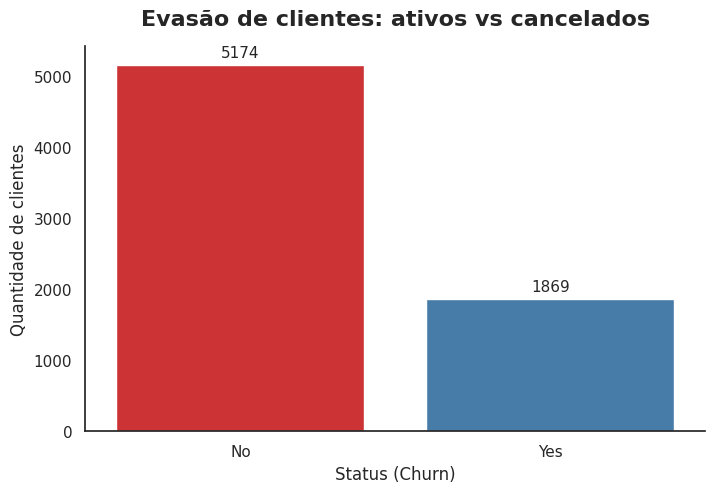

In [84]:
sns.set_theme(style="white")

plt.figure(figsize=(8, 5))

ax = sns.countplot(data = df_telecom, x = "Churn", hue = "Churn", palette = "Set1")

plt.title("Evasão de clientes: ativos vs cancelados", fontsize = 16, fontweight = "bold", pad = 15)
plt.xlabel("Status (Churn)", fontsize = 12)
plt.ylabel("Quantidade de clientes", fontsize = 12)

sns.despine()

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

plt.show()

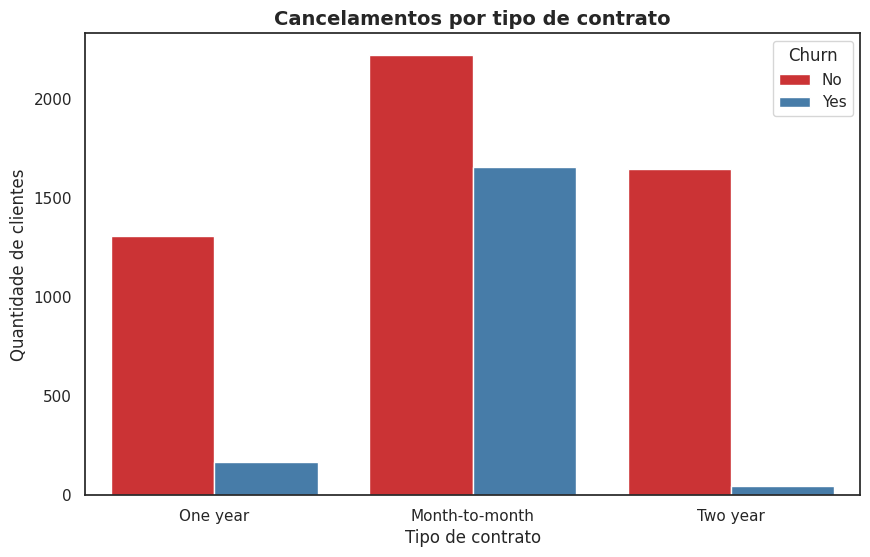

In [85]:
plt.figure(figsize=(10, 6))
sns.countplot(data = df_telecom, x = "account.Contract", hue="Churn", palette = "Set1")

plt.title("Cancelamentos por tipo de contrato", fontweight = "bold", fontsize = 14)
plt.xlabel("Tipo de contrato", fontsize = 12)
plt.ylabel("Quantidade de clientes", fontsize = 12)

plt.show()

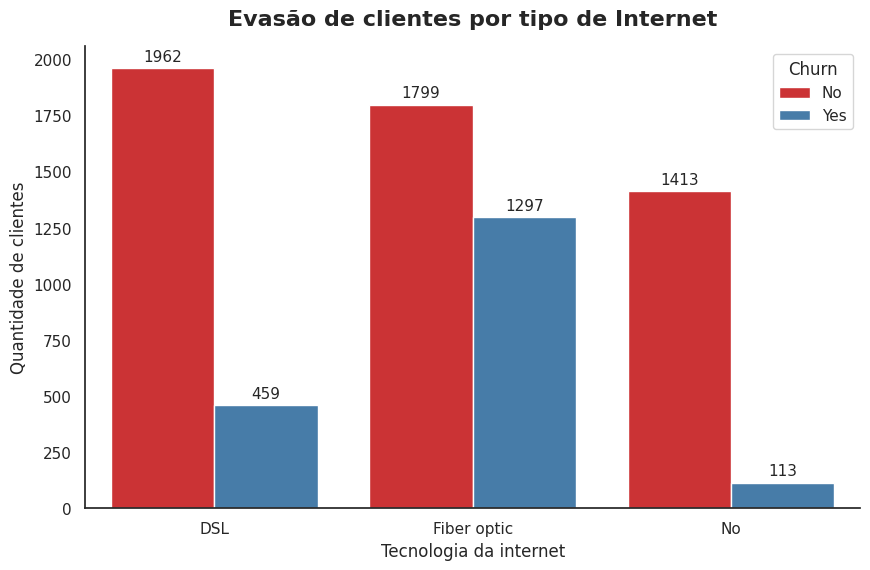

In [86]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(data = df_telecom, x = "internet.InternetService", hue = "Churn", palette = "Set1")

plt.title("Evasão de clientes por tipo de Internet", fontsize = 16, fontweight = "bold", pad=15)
plt.xlabel("Tecnologia da internet", fontsize = 12)
plt.ylabel("Quantidade de clientes", fontsize = 12)

sns.despine()

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

plt.show()

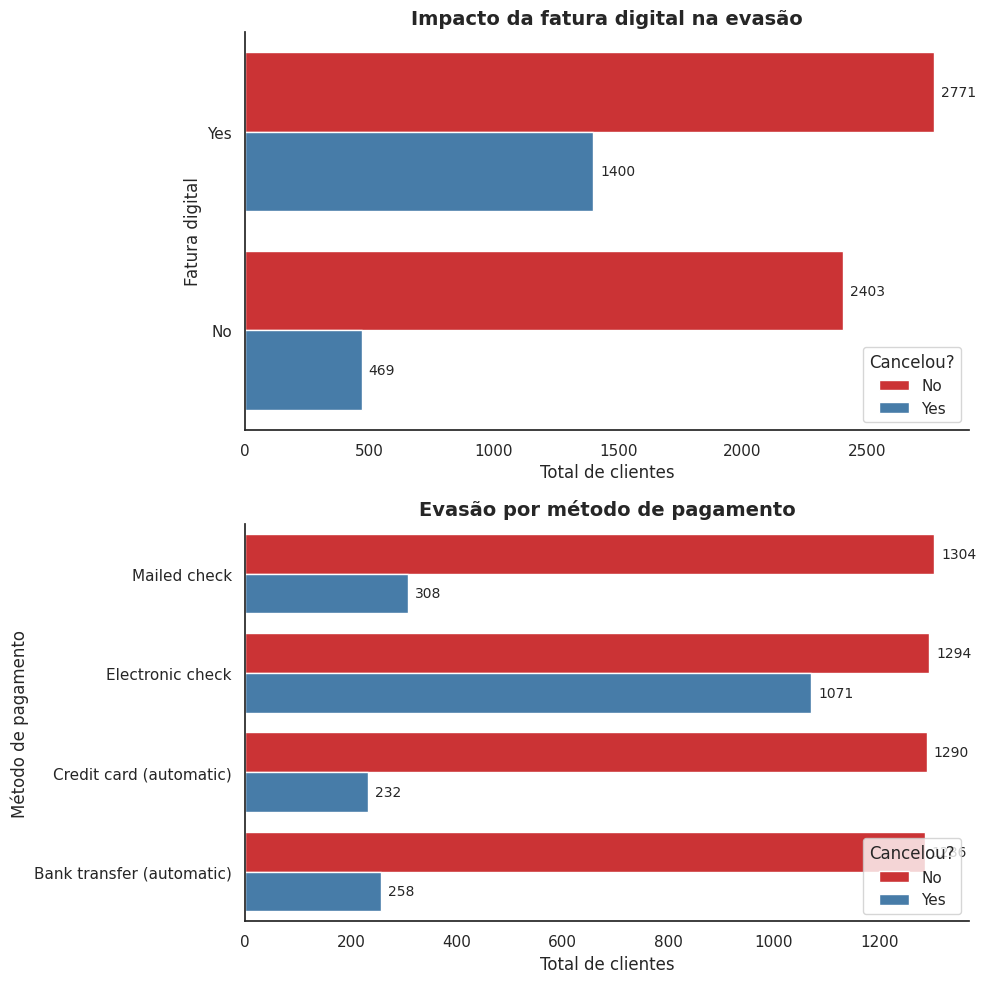

In [87]:
# Optei por trabalhar com dois gráficos na horizontal
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1° gráfico: fatura digital
sns.countplot(data= df_telecom, y= "account.PaperlessBilling", hue= "Churn",
              palette= "Set1", ax= axes[0], hue_order= ["No", "Yes"])
axes[0].set_title("Impacto da fatura digital na evasão", fontsize= 14, fontweight= "bold")
axes[0].set_ylabel("Fatura digital", fontsize= 12)
axes[0].set_xlabel("Total de clientes", fontsize= 12)
axes[0].legend(title='Cancelou?', loc='lower right')

# 2° gráfico: método de pagamento
sns.countplot(data= df_telecom, y= "account.PaymentMethod", hue= "Churn",
              palette= "Set1", ax=axes[1], hue_order=["No", "Yes"])
axes[1].set_title("Evasão por método de pagamento", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Método de pagamento", fontsize= 12)
axes[1].set_xlabel("Total de clientes", fontsize= 12)
axes[1].legend(title='Cancelou?', loc='lower right')

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, padding= 5, fontsize= 10)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

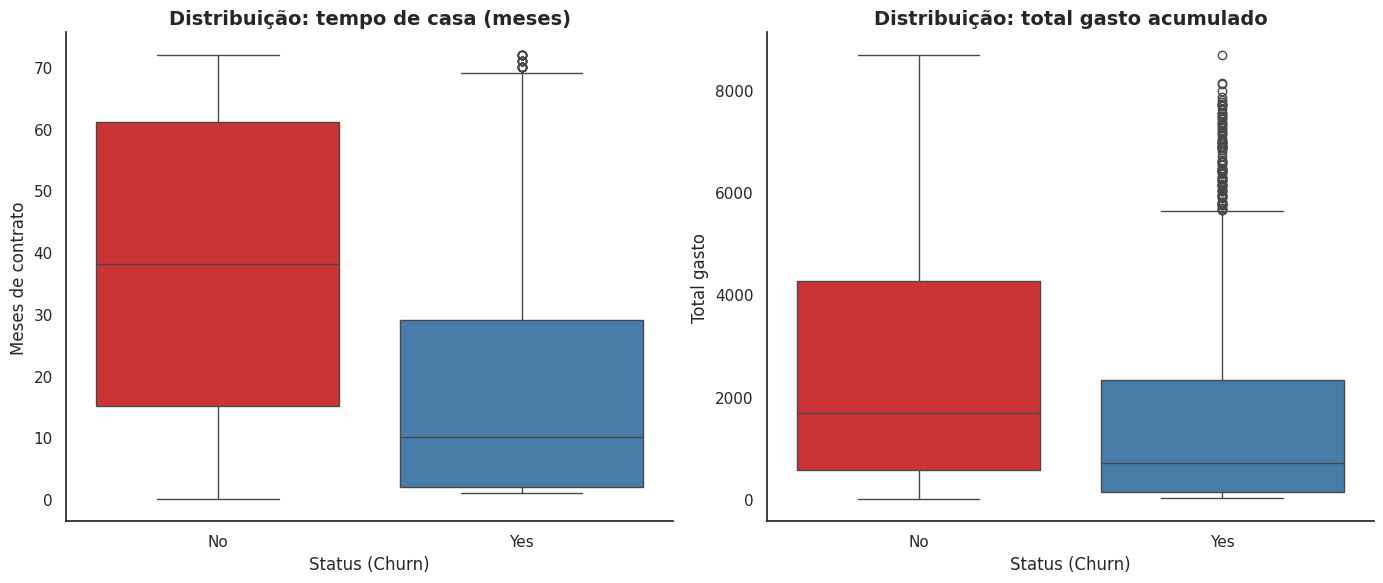

In [88]:
# Criando um comparativo utilizando dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1º gráfico: distribuição do tempo de casa
sns.boxplot(data=df_telecom, x="Churn", y="customer.tenure", hue="Churn",
            palette="Set1", ax=axes[0], legend=False)
axes[0].set_title("Distribuição: tempo de casa (meses)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Meses de contrato", fontsize=12)
axes[0].set_xlabel("Status (Churn)", fontsize=12)

# 2º gráfico: distribuição do total gasto
sns.boxplot(data=df_telecom, x="Churn", y="account.Charges.Total", hue="Churn",
            palette="Set1", ax=axes[1], legend=False)
axes[1].set_title("Distribuição: total gasto acumulado", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Total gasto", fontsize=12)
axes[1].set_xlabel("Status (Churn)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

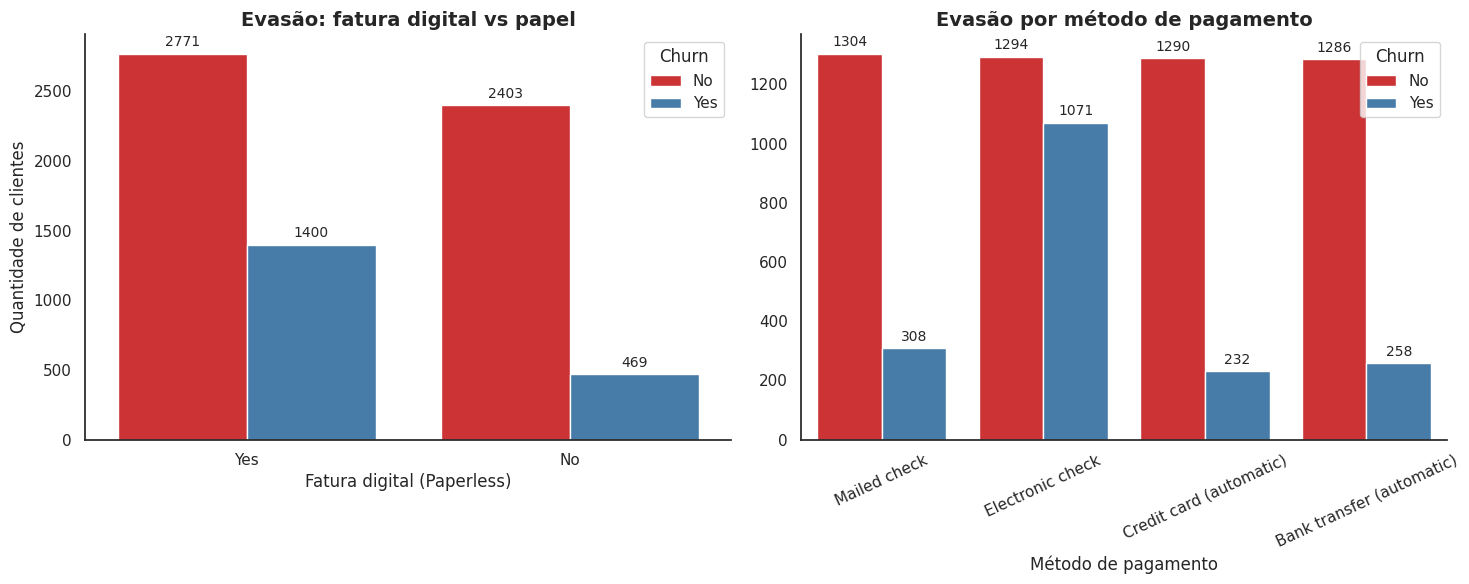

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cores_churn = {'No': '#7f8c8d', 'Yes': '#e74c3c'}

# 1° gráfico: fatura digital (PaperlessBilling)
ax1 = sns.countplot(data= df_telecom, x= "account.PaperlessBilling", hue= "Churn",
                    palette= "Set1", ax=axes[0])
axes[0].set_title("Evasão: fatura digital vs papel", fontsize= 14, fontweight= "bold")
axes[0].set_xlabel("Fatura digital (Paperless)", fontsize= 12)
axes[0].set_ylabel("Quantidade de clientes", fontsize= 12)

for container in ax1.containers:
    ax1.bar_label(container, padding= 3, fontsize= 10)

# 2° gráfico: método de pagamento (PaymentMethod)
ax2 = sns.countplot(data= df_telecom, x= "account.PaymentMethod", hue= "Churn",
                    palette= "Set1", ax=axes[1])
axes[1].set_title("Evasão por método de pagamento", fontsize= 14, fontweight= "bold")
axes[1].set_xlabel("Método de pagamento", fontsize= 12)
axes[1].set_ylabel("") # Removendo para deixar mais limpo

axes[1].tick_params(axis='x', rotation=25)

for container in ax2.containers:
    ax2.bar_label(container, padding= 3, fontsize= 10)

sns.despine()
plt.tight_layout()
plt.show()


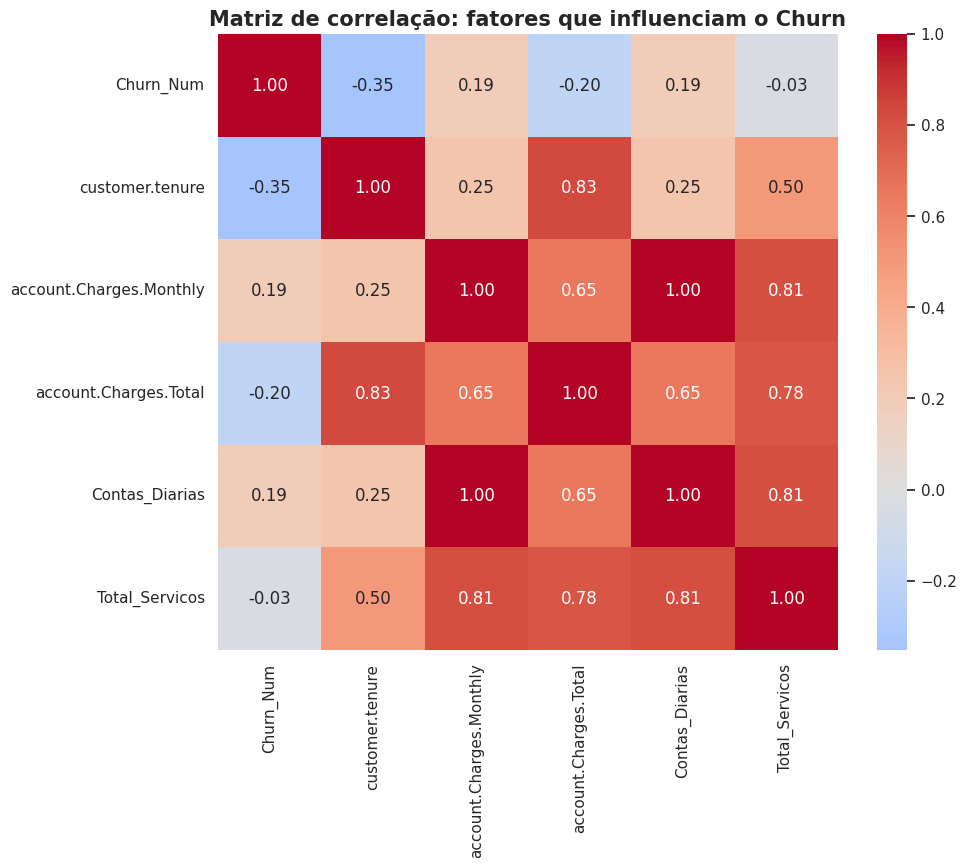

In [90]:
# Optei por criar uma cópia para não alterar o dataframe original
df_corr = df_telecom.copy()

# Transformei Churn em 0 (No) e 1 (Yes) de forma explícita para evitar o aviso
df_corr["Churn_Num"] = pd.to_numeric(df_corr["Churn"].replace({"No": 0, "Yes": 1}))
colunas_analise = [
    "Churn_Num",
    "customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total",
    "Contas_Diarias",
    "Total_Servicos"
]

# O restante do código da matriz permanece igual
matriz_correlacao = df_corr[colunas_analise].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Matriz de correlação: fatores que influenciam o Churn", fontsize=15, fontweight="bold")
plt.show()

# **Relatório final**

##  **1. Resumo do Projeto**
Este projeto realizou o processo completo de ETL e Análise Exploratória (EDA) sobre a base de dados de Churn da Telecom X. O objetivo foi identificar os gatilhos que levam um cliente a cancelar o serviço.

## **2. Insights Estratégicos Baseados em Dados**

* O ponto de atrito financeiro: clientes que cancelam pagam, em média, 21% a mais mensalmente do que os clientes retidos. A matriz de correlação confirmou que o custo diário/mensal tem uma relação positiva com a evasão.

* A fragilidade dos novos clientes: a mediana de tempo de casa de quem cancela é de apenas 10 meses, contra 38 meses de quem fica. A forte correlação negativa entre tenure e Churn (-0.35) prova que, quanto mais tempo o cliente permanece, menor a chance de ele sair.

* O problema da fibra óptica  e pagamento manual: o serviço de fibra óptica sozinho registrou 1.297 cancelamentos. Além disso, o método de "Eletronic Check" apresenta a maior taxa de evasão proporcional, sugerindo que métodos de pagamento não automáticos facilitam o cancelamento.

* O efeito blindagem: criamos a variável "Total_Servicos" e provamos que clientes com 5 ou mais serviços contratados raramente cancelam, independente do valor da conta.

##**3. Recomendações de Negócio**

* Fidelização: criar campanhas para migrar clientes de contratos "Month to Month" para anuais, focando especialmente naqueles que estão nos primeiros 12 meses de contrato.

* Incentivo ao débito automático: oferecer pequenos descontos para clientes que saírem do "Electronic Check" para "Credit Card (automatic)", reduzindo o atrito no pagamento.

* Auditoria na fibra óptica: investigar a estabilidade da rede de fibra óptica, já que ela é o produto com maior volume de perdas financeiras.